# Practical Application III: Comparing Classifiers

## Overview
The **business goal** is to improve the effectiveness of marketing campaigns for long-term deposit subscriptions by reducing the number of marketing contacts (according to Moro et. al 2014). 

To achieve this goal, this assigment compares the performance of several classifiers (K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines) for predicting whether a client will subscribe to a term deposit, and recommends using the preferred model to rank clients by predicted probability and prioritize calls within the bank’s marketing outreach effort.


### Problem 1: Understanding the Data

According to Moro et. al 2014 paper, How many marketing campaigns does this data represent?

In [112]:
17

17

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import time

In [114]:
#Import full databset (41188 obs; 1 outcome + 20 attributes)
df = pd.read_csv('/Users/ceci/Library/Mobile Documents/com~apple~CloudDocs/MLAI_Berkeley/Modules/Module 17 Practical Application 3/module17_starter/data/bank-additional-full.csv', sep = ';')

In [115]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [116]:
## Load bank-additional.csv with 10% of the examples (4119) to test SVM model due to the computational requirements.
df2 = pd.read_csv('/Users/ceci/Library/Mobile Documents/com~apple~CloudDocs/MLAI_Berkeley/Modules/Module 17 Practical Application 3/module17_starter/data/bank-additional.csv', sep = ';')

### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

Input variables:

**bank client data**

- age (numeric)
- job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
- marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
- education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
- default: has credit in default? (categorical: 'no','yes','unknown')
- housing: has housing loan? (categorical: 'no','yes','unknown')
- loan: has personal loan? (categorical: 'no','yes','unknown')

**Related with the last contact of the current campaign**
- contact: contact communication type (categorical: 'cellular','telephone')
- month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
- day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
- duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

**Other attributes**
- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
- previous: number of contacts performed before this campaign and for this client (numeric)
- poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

**Social and economic context attributes**
- emp.var.rate: employment variation rate - quarterly indicator (numeric)
- cons.price.idx: consumer price index - monthly indicator (numeric)
- cons.conf.idx: consumer confidence index - monthly indicator (numeric)
- euribor3m: euribor 3 month rate - daily indicator (numeric)
- nr.employed: number of employees - quarterly indicator (numeric)

**Output variable (desired target)**
- y: has the client subscribed a term deposit? (binary: 'yes','no')

**Missingness assessment**:
- The dataset is already very clean, with no missing values. Information is also relatively complete, with only a few variables containing "unknown" values. default has the largest share of "unknown" responses, at about 20%.

In [117]:
# Count missing values (NaN)
missing = df.isna().sum()

# Count "unknown" values
unknown = (df == "unknown").sum()

# Create summary table
missing_summary = pd.DataFrame({
    "Missing (NaN)": missing,
    "Unknown": unknown,
    "Total Missing/Unknown": missing + unknown,
    "Percent Missing/Unknown": ((missing + unknown) / len(df) * 100).round(1)
})

# Show variables with any missing or unknown values
missing_summary = missing_summary[
    missing_summary["Total Missing/Unknown"] > 0
]

missing_summary.sort_values(
    "Percent Missing/Unknown",
    ascending=False
)

,Missing (NaN),Unknown,Total Missing/Unknown,Percent Missing/Unknown
default,0,8597,8597,20.9
education,0,1731,1731,4.2
housing,0,990,990,2.4
loan,0,990,990,2.4
job,0,330,330,0.8
marital,0,80,80,0.2


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

As described in [Moro et al., 2014], the **business goal** is to improve the effectiveness of marketing campaigns for long-term deposit subscriptions by reducing the number of marketing contacts.

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations. This step means that before building the model, you need to preprocess the data. Specifically, use only the bank-related features, convert categorical variables into numerical form (e.g., using encoding techniques like one-hot encoding or label encoding), and define your target variable separately. The final output should be a feature matrix (X) and a target column (y) ready for modeling.

- I used **one-hot encoding** (through `pd.get_dummies()`) to convert categorical predictor variables into numerical features for modeling.
- I used **binary encoding** to convert the target variable from `yes/no` to `1/0`.

In [119]:
# =========================================
# FEATURE ENGINEERING - FULL DATASET
# =========================================

features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "poutcome",
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "poutcome",
]

# Target
df["subscribed"] = df["y"].map({
    "no": 0,
    "yes": 1
})

y = df["subscribed"].copy()

# Predictors
X = df[features].copy()

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Full dataset")
print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================================
# FEATURE ENGINEERING - SMALLER DATASET FOR SVM
# =========================================

df2["subscribed"] = df2["y"].map({
    "no": 0,
    "yes": 1
})

y2 = df2["subscribed"].copy()

X2 = df2[features].copy()

X2 = pd.get_dummies(
    X2,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("SVM dataset")
print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

Full dataset
X shape: (41188, 26)
y shape: (41188,)
SVM dataset
X2 shape: (4119, 26)
y2 shape: (4119,)


**Understanding how subscription rates vary by groups**
- Through this process, I find that some features are more strongly associated with subscription rates than others. For example, age, education, job, if they had credit in default, prior outcome (in a prior campaign), appear important features to include in the model,  while whether they have taken a housing or personal loan does not seem to matter much. 
- Subscription rates appear higher among younger and older clients and lower among middle-aged clients. One possible explanation is that middle-aged clients face greater competing financial obligations, while older clients may have more accumulated savings and a stronger preference for relatively low-risk savings products. These patterns are descriptive and do not establish the reasons for the differences.
- For visualizations, I experimented with stacked charts to show not only subscription rates but also the number of clients in each group. I also improved the exposition by including key calculated statistics directly in the chart titles, and combining several graphs in a single figure. 

In [120]:
# Subscription rate by previous campaign outcome
subscription_rate = (
    df.groupby("poutcome")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .round(1)
)

print(subscription_rate)

poutcome
failure        14.2
nonexistent     8.8
success        65.1
Name: y, dtype: float64


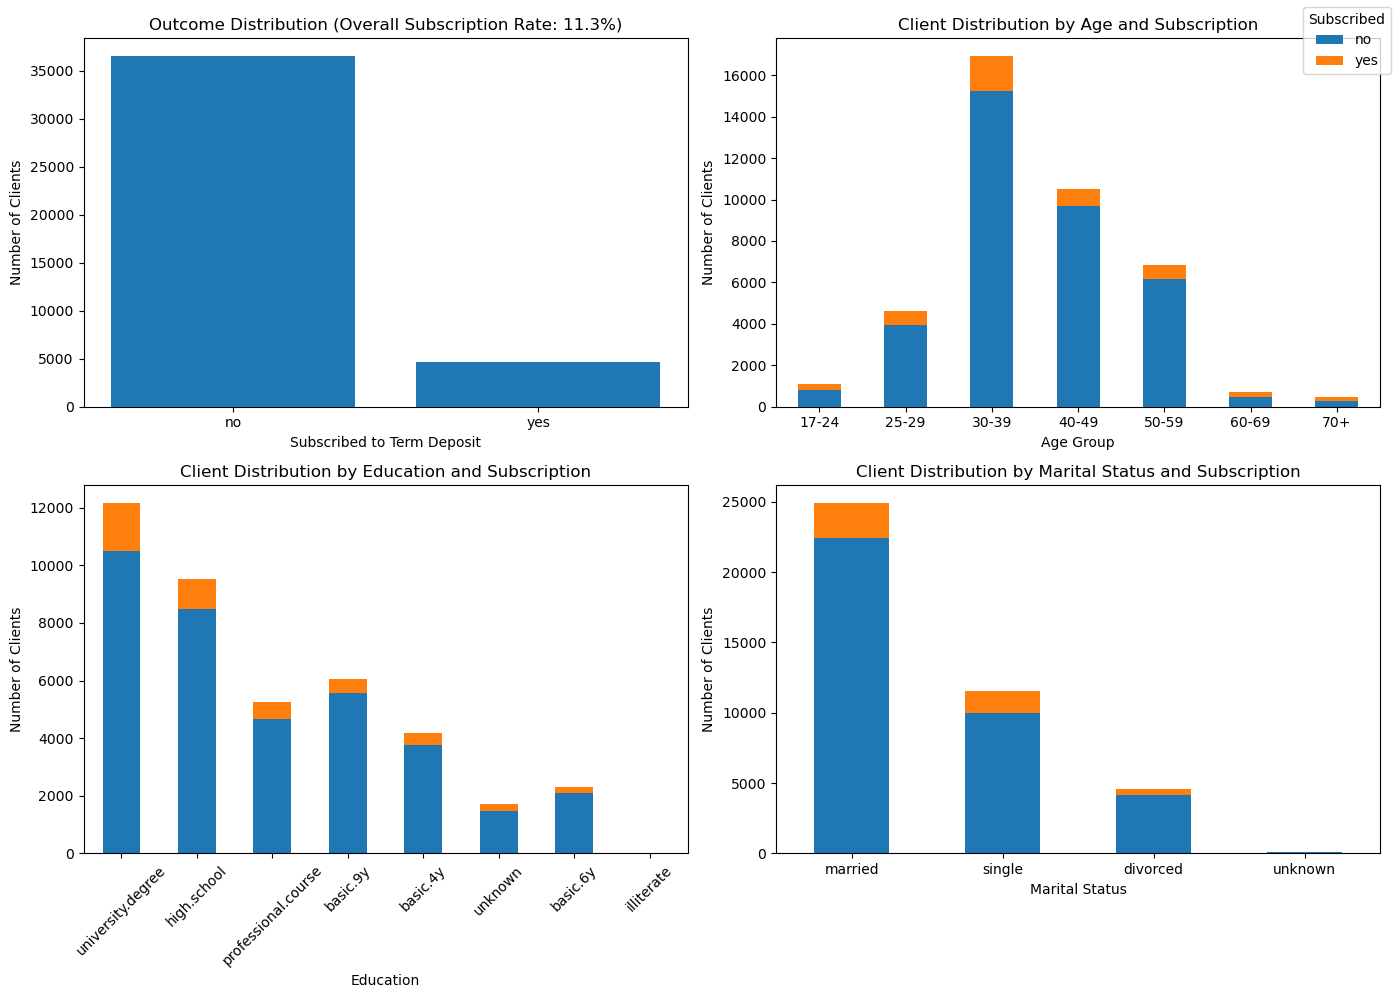

In [121]:
# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 30, 40, 50, 60, 70, float("inf")],
    labels=["17-24", "25-29", "30-39", "40-49", "50-59", "60-69", "70+"],
    right=False
)

# Create 2 x 2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall outcome distribution
outcome = df["y"].value_counts()

# Calculate overall subscription rate
overall_rate = (df["y"] == "yes").mean() * 100

axes[0, 0].bar(
    outcome.index,
    outcome.values
)

axes[0, 0].set_title(
    f"Outcome Distribution (Overall Subscription Rate: {overall_rate:.1f}%)"
)

axes[0, 0].set_xlabel("Subscribed to Term Deposit")
axes[0, 0].set_ylabel("Number of Clients")


# 2. Age group by subscription outcome
age_outcome = pd.crosstab(
    df["age_group"],
    df["y"]
)

age_outcome.plot(
    kind="bar",
    stacked=True,
    ax=axes[0, 1],
    legend=False
)

axes[0, 1].set_title("Client Distribution by Age and Subscription")
axes[0, 1].set_xlabel("Age Group")
axes[0, 1].set_ylabel("Number of Clients")
axes[0, 1].tick_params(axis="x", rotation=0)


# 3. Education by subscription outcome
education_outcome = pd.crosstab(
    df["education"],
    df["y"]
)

# Sort by number of "yes" subscriptions
education_outcome = education_outcome.sort_values(
    by="yes",
    ascending=False
)

education_outcome.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 0],
    legend=False
)

axes[1, 0].set_title("Client Distribution by Education and Subscription")
axes[1, 0].set_xlabel("Education")
axes[1, 0].set_ylabel("Number of Clients")
axes[1, 0].tick_params(axis="x", rotation=45)


# 4. Marital status by subscription outcome
marital_outcome = pd.crosstab(
    df["marital"],
    df["y"]
)

# Sort by number of "yes" subscriptions
marital_outcome = marital_outcome.sort_values(
    by="yes",
    ascending=False
)

marital_outcome.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 1],
    legend=False
)

axes[1, 1].set_title("Client Distribution by Marital Status and Subscription")
axes[1, 1].set_xlabel("Marital Status")
axes[1, 1].set_ylabel("Number of Clients")
axes[1, 1].tick_params(axis="x", rotation=0)


# Shared legend
handles, labels = axes[0, 1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Subscribed",
    loc="upper right"
)

plt.tight_layout()
plt.show()

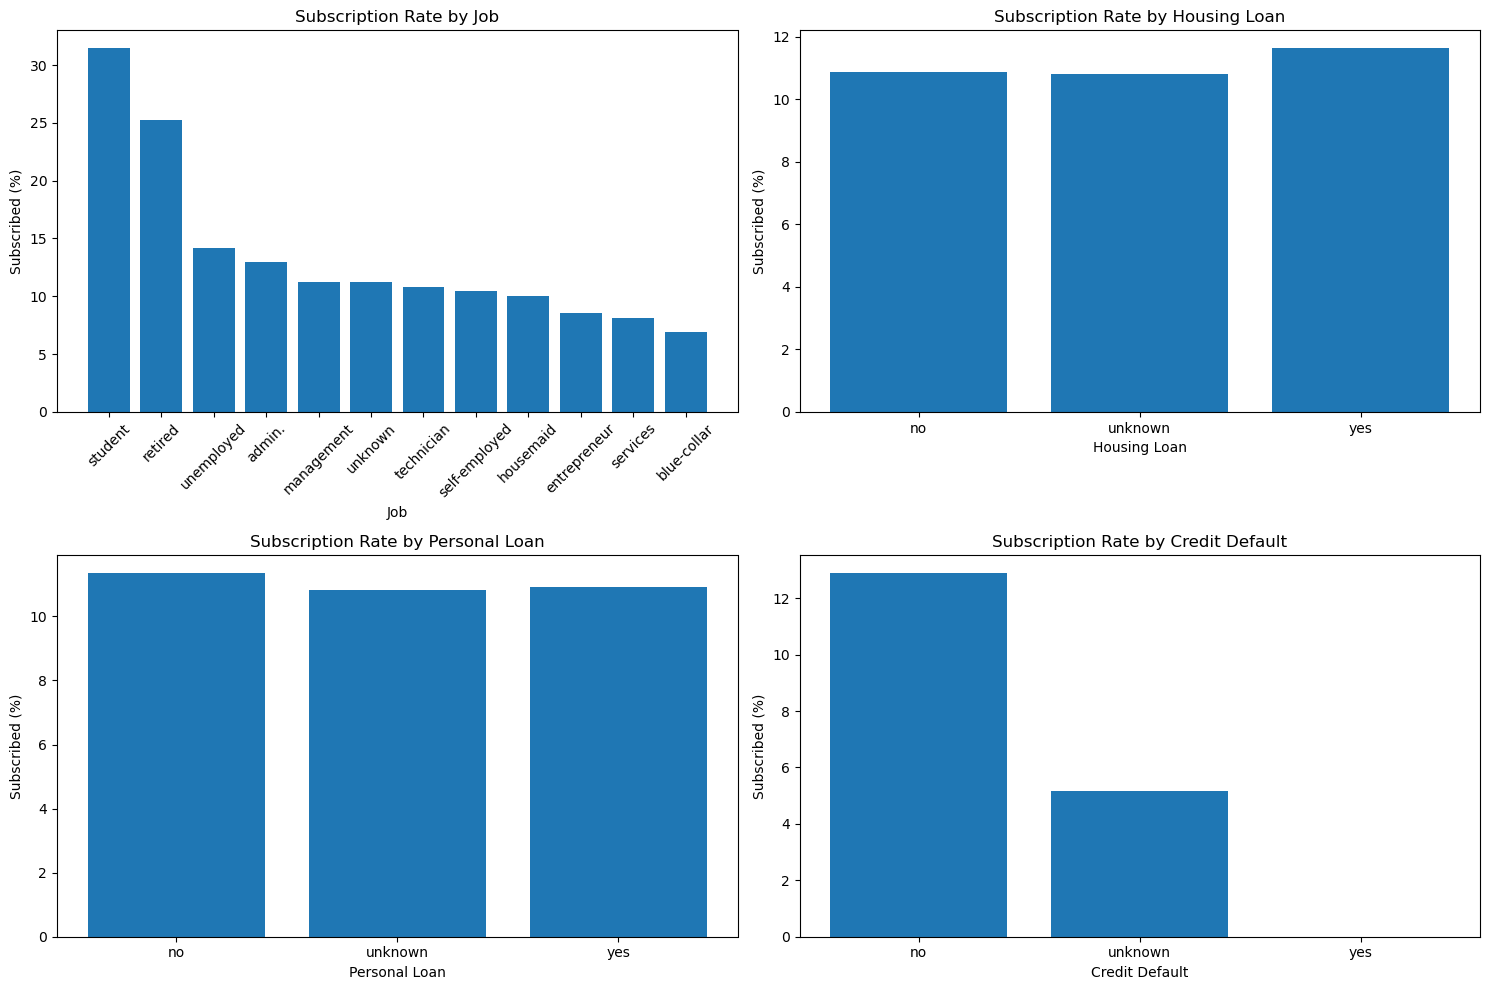

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


# 1. Subscription rate by job
job_rate = (
    df.groupby("job")["subscribed"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

axes[0, 0].bar(job_rate.index, job_rate.values)
axes[0, 0].set_title("Subscription Rate by Job")
axes[0, 0].set_xlabel("Job")
axes[0, 0].set_ylabel("Subscribed (%)")
axes[0, 0].tick_params(axis="x", rotation=45)


# 2. Subscription rate by housing loan
housing_rate = (
    df.groupby("housing")["subscribed"]
      .mean()
      .mul(100)
)

axes[0, 1].bar(housing_rate.index, housing_rate.values)
axes[0, 1].set_title("Subscription Rate by Housing Loan")
axes[0, 1].set_xlabel("Housing Loan")
axes[0, 1].set_ylabel("Subscribed (%)")


# 3. Subscription rate by personal loan
loan_rate = (
    df.groupby("loan")["subscribed"]
      .mean()
      .mul(100)
)

axes[1, 0].bar(loan_rate.index, loan_rate.values)
axes[1, 0].set_title("Subscription Rate by Personal Loan")
axes[1, 0].set_xlabel("Personal Loan")
axes[1, 0].set_ylabel("Subscribed (%)")


# 4. Subscription rate by credit default
default_rate = (
    df.groupby("default")["subscribed"]
      .mean()
      .mul(100)
)

axes[1, 1].bar(default_rate.index, default_rate.values)
axes[1, 1].set_title("Subscription Rate by Credit Default")
axes[1, 1].set_xlabel("Credit Default")
axes[1, 1].set_ylabel("Subscribed (%)")


plt.tight_layout()
plt.show()

### Problem 6: Train/Test Split

- Now that data is prepared, I split it into a train and test set, separately for the full and smaller random sample provided. 
- Given that my outcome is highly imbalanced, I stratifying by the outcome to preserve the same proportion of yes and no outcomes in both train/test sets.

In [123]:
# Full dataset: Logistic Regression, KNN, Decision Tree
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42,stratify=y)

# Smaller provided dataset: SVM
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size=0.20,random_state=42,stratify=y2)

### Problem 7: A Baseline Model
What is the baseline performance that our classifier should aim to beat?
- A baseline model would simply predict the most common outcome (no subscription) for everyone. In terms of accuracy, this "model" performs very well (accurately predicting the outcome 88.7% of the time). However, this baseline model is not useful - as banks value correctly identifying clients who are likely to subscribe and the baseline model fails to identify any potential subscribers. I therefore estimate alternative classification models that can better identify likely subscribers.
- Since this baseline model never predicts "yes", this baseline model, has:
    - Recall (Of all the clients who actually subscribed, how many did the model identify?) = 0 
    - Precision (Of all the clients the model predicted would subscribe, how many actually subscribed?)= undefined (or 0)
- Note that I get the same baseline accuracy in the full sample than in my test sample because I am stratifying on the outcome when creating the split. 

In [124]:
# Baseline accuracy = proportion of majority class
baseline_accuracy = y.value_counts(normalize=True).max()

print(f"\nBaseline Accuracy: {baseline_accuracy:.3f}")

# Baseline accuracy = proportion of majority class in the test set
baseline_accuracy = y_test.value_counts(normalize=True).max()

print(f"Baseline Test Accuracy: {baseline_accuracy:.3f}")

print("Full sample:", len(y))
print("Training sample:", len(y_train))
print("Test sample:", len(y_test))

print("Train + Test:", len(y_train) + len(y_test))


Baseline Accuracy: 0.887
Baseline Test Accuracy: 0.887
Full sample: 41188
Training sample: 32950
Test sample: 8238
Train + Test: 41188


### Problem 8: A Simple Model

Used Logistic Regression to build a basic model on your data.  

In [125]:
# Logistic Regression pipeline
logistic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Fit model on training data
logistic_pipe.fit(X_train, y_train)

# Predict on test data
logistic_preds = logistic_pipe.predict(X_test)

### Problem 9: Score the Model

What is the accuracy of your model?
- Logit model accuracy was 89% - which is higher (though remarkably similar) than your 88.7% baseline accuracy. Reading the numbers from the confusion matrix: the logit model performs very well at identifying non-subscribers, correctly classifying 7,232 clients and incorrectly targeting only 78 non-subscribers.
- However, the model performs poorly at identifying potential subscribers: it correctly identifies only 175 of 928 actual subscribers (19% recall), missing 753 potential subscribers (that is, the model still misses 81% of actual subscribers).

In [126]:
# Calculate performance metrics
logistic_accuracy = accuracy_score(y_test, logistic_preds)
logistic_precision = precision_score(y_test, logistic_preds, zero_division=0)
logistic_recall = recall_score(y_test, logistic_preds, zero_division=0)

print(f"Accuracy:  {logistic_accuracy:.3f}")
print(f"Precision: {logistic_precision:.3f}")
print(f"Recall:    {logistic_recall:.3f}")

Accuracy:  0.899
Precision: 0.692
Recall:    0.189


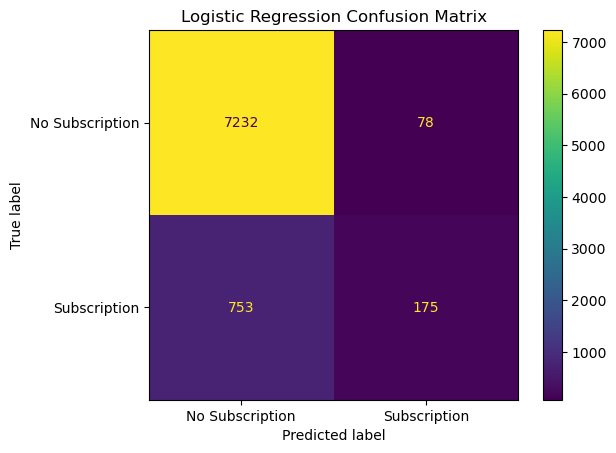

In [127]:
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_preds,
    display_labels=["No Subscription", "Subscription"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Problem 10: Model Comparisons

Using default settings (no tunning parameters), I compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  
- I find that SVM achieved the highest test accuracy (90.4%), followed closely by Logistic Regression (89.9%). Decision Tree showed the largest gap between training and test accuracy, suggesting some overfitting (but not too bad).
- SVM is the most computationally timeconsuming - even though I run this model on the smaller databaset df2.  

In [128]:

# --------------------------------------------------
# Define models using default model settings
# --------------------------------------------------

models = {
    
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression())
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    
    "Decision Tree": DecisionTreeClassifier(),
}


# --------------------------------------------------
# Fit models using full dataset
# --------------------------------------------------

results = []

for name, model in models.items():
    
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    
    results.append({
        "Model": name,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })


# --------------------------------------------------
# SVM - use smaller provided dataset (df2)
# --------------------------------------------------

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

start_time = time.time()

svm_model.fit(X2_train, y2_train)

svm_train_time = time.time() - start_time

svm_train_accuracy = svm_model.score(X2_train, y2_train)
svm_test_accuracy = svm_model.score(X2_test, y2_test)

results.append({
    "Model": "SVM (df2)",
    "Train Time": svm_train_time,
    "Train Accuracy": svm_train_accuracy,
    "Test Accuracy": svm_test_accuracy
})


# --------------------------------------------------
# Results table
# --------------------------------------------------

results_df = pd.DataFrame(results)

results_df["Train Time"] = results_df["Train Time"].round(3)
results_df["Train Accuracy"] = results_df["Train Accuracy"].round(3)
results_df["Test Accuracy"] = results_df["Test Accuracy"].round(3)

display(results_df)

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.039,0.898,0.899
1,KNN,0.009,0.902,0.891
2,Decision Tree,0.055,0.919,0.881
3,SVM (df2),0.142,0.903,0.904


### Problem 11: Improving the Model

In this section, I improve the models by tunning hyperparameters.

Because the target variable is imbalanced and the business objective is to identify potential subscribers, I use recall rather than accuracy as the primary performance metric for model tuning. I use 5-fold cross-validation with grid search to select hyperparameters that maximize recall.
 
 - Logistic Regression: Tune C which controls the amount of regularization

 - KNN: Tune the number of neighbors

 - Decision tree: Tune max depth of a decision tree and minimun leaf size

 - SVM: Tune C and kernel

#### Tune Logistic Regression

In [129]:
logistic_grid = {
    "logistic__C": [0.01, 0.1, 1, 10, 100]
}

logistic_search = GridSearchCV(
    logistic_pipe,
    logistic_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

logistic_search.fit(X_train, y_train)

print("Best parameters:", logistic_search.best_params_)
print("Best CV Recall:", round(logistic_search.best_score_, 3))

Best parameters: {'logistic__C': 0.01}
Best CV Recall: 0.186


#### Tune KNN Regression

In [130]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21]
}

knn_search = GridSearchCV(
    knn_pipe,
    knn_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

print("Best parameters:", knn_search.best_params_)
print("Best CV Recall:", round(knn_search.best_score_, 3))

Best parameters: {'model__n_neighbors': 3}
Best CV Recall: 0.194


#### Tune Decision Tree

In [131]:
tree_grid = {
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_leaf": [1, 5, 10, 20]
}

tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

tree_search.fit(X_train, y_train)

print("Best parameters:", tree_search.best_params_)
print("Best CV Recall:", round(tree_search.best_score_, 3))

Best parameters: {'max_depth': 3, 'min_samples_leaf': 10}
Best CV Recall: 0.187


### Tune SVM using df2

In [132]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

svm_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"]
}

svm_search = GridSearchCV(
    svm_pipe,
    svm_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

svm_search.fit(X2_train, y2_train)

print("Best parameters:", svm_search.best_params_)
print("Best CV Recall:", round(svm_search.best_score_, 3))

Best parameters: {'model__C': 0.1, 'model__kernel': 'linear'}
Best CV Recall: 0.208


### Compare all tuned models

- Overall, the tuned models have similar recall (18–19%), and all of them still identify fewer than one in five actual subscribers. Tuning the hyperparameters did not meaningfully improve the models’ ability to identify subscribers.
- SVM has the strongest overall performance, with the highest test accuracy (90.5%), precision (77.3%), F1 score (0.304), and tied for the highest test recall (18.9%). However, SVM was estimated on the smaller df2 sample, so we would have to see if it holds true in the full sample.
- Logistic Regression is my preferred model for deployment. Its test accuracy is nearly as high (89.9%), it has relatively strong precision (69.0%), and its recall and F1 are very similar to the other models. It further has the advantage of being simpler to estimate and interpret.

Practical business recommendations: 
- The preferred model is a logit for this application. Although it did not have the highest recall, it is simpler and more interpretable than more computationally intensive approaches, while still achieving very similar predictive performance.  
- Instead of using the model to just predicting whether someone would subscribe, I'd recommend that banks use it to prioritize scarce marketing effort. If you have a budget to make, say, 1000 calls, then rank clients by the predicted probability and contact the top 1000 prospects.
- Try different marketing strategies and compared subcriptions obtained per 1,000 contacts amidst marketing cost.

In [133]:
# Store tuned models and corresponding test data
tuned_models = {
    "Logistic Regression": (
        logistic_search,
        X_test,
        y_test
    ),
    
    "KNN": (
        knn_search,
        X_test,
        y_test
    ),
    
    "Decision Tree": (
        tree_search,
        X_test,
        y_test
    ),
    
    # SVM uses smaller provided df2
    "SVM (df2)": (
        svm_search,
        X2_test,
        y2_test
    )
}


# Collect results
tuned_results = []

for name, (search, X_eval, y_eval) in tuned_models.items():
    
    # Best model selected by GridSearchCV
    best_model = search.best_estimator_
    
    # Test predictions
    preds = best_model.predict(X_eval)
    
    tuned_results.append({
        "Model": name,
        "Best Parameters": search.best_params_,
        "CV Recall": search.best_score_,
        "Test Accuracy": accuracy_score(y_eval, preds),
        "Test Precision": precision_score(
            y_eval, preds, zero_division=0
        ),
        "Test Recall": recall_score(
            y_eval, preds, zero_division=0
        ),
        "Test F1": f1_score(
            y_eval, preds, zero_division=0
        )
    })


# Create results table
tuned_results_df = pd.DataFrame(tuned_results)

# Round performance metrics
metric_columns = [
    "CV Recall",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1"
]

tuned_results_df[metric_columns] = (
    tuned_results_df[metric_columns].round(3)
)

display(tuned_results_df)

,Model,Best Parameters,CV Recall,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,{'logistic__C': 0.01},0.186,0.899,0.690,0.188,0.295
1,KNN,{'model__n_neighbors': 3},0.194,0.878,0.412,0.183,0.254
2,Decision Tree,"{'max_depth': 3, 'min_samples_leaf': 10}",0.187,0.898,0.673,0.189,0.295
3,SVM (df2),"{'model__C': 0.1, 'model__kernel': 'linear'}",0.208,0.905,0.773,0.189,0.304


**Next Steps for modeling**: As an alternative to ranking clients by predicted probability to prioritize calls, one could explore different classification thresholds for Logistic Regression and assess the trade-offs between precision and recall when turning predicted probabilities into an operational targeting rule.

The next improvement I would explore is the classification threshold for Logistic Regression rather than simply more hyperparameter tuning. Scikit-learn defaul setting uses a 0.5 threshold with .predict() for classifying 1/0 based on predicted probabilities. The default 0.5 threshold is high for this application, and is contributing to very low recall. 

The bank doesn't necessarily care whether someone's predicted probability crosses the arbitrary 50% line. It cares about whether that person is worth contacting. From the bank's perspective, a client with a 30% chance of subscribing may be an excellent candidate for marketing, especially when the average subscription rate is only about 11%.  

The choice of classification threshold should reflect the bank's business objectives and the relative costs of prediction errors. Lowering the threshold below the default of 0.50 would identify more potential subscribers and increase recall, but it would also reduce precision and result in more unsuccessful marketing contacts. Because the goal -- as stated in the Moro et. al 2014-- is to improve marketing effectiveness while reducing the number of contacts, the bank should not necessarily choose the threshold that maximizes recall. Instead, it should select a threshold that identifies a sufficiently large share of potential subscribers while avoiding excessive contacts with clients unlikely to subscribe. If the cost of making an additional marketing contact is relatively low compared with the value of gaining a term-deposit customer, the bank may reasonably favor a lower threshold and accept some reduction in precision. Even though marketing calls are cheap and value of a new customer large, we should not simply lowered the threshold as far as possible since that would increase contacts and work against the stated objective of reducing marketing effort! 